# Transfer learning with YAMNet for environmental sound classification

[YAMNet](https://tfhub.dev/google/yamnet/1) is a pre-trained deep neural network that can predict audio events from [521 classes](https://github.com/tensorflow/models/blob/master/research/audioset/yamnet/yamnet_class_map.csv), such as laughter, barking, or a siren. 

 In this tutorial you will learn how to:

- Load and use the YAMNet model for inference.
- Build a new model using the YAMNet embeddings to classify cat and dog sounds.
- Evaluate and export your model.


## Import TensorFlow and other libraries


Start by installing [TensorFlow I/O](https://www.tensorflow.org/io), which will make it easier for you to load audio files off disk.

In [26]:
import pandas as pd
import plotly.express as px
import os

from IPython import display
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import tqdm

import tensorflow as tf
import tensorflow_hub as hub
import tensorflow_io as tfio
from tensorflow.keras import regularizers

import params as yamnet_params
import yamnet as yamnet_model

In [27]:
print("TensorFlow Version:", tf.__version__)
print("TensorFlow Hub Version:", hub.__version__)
print("TensorFlow I/O Version:", tfio.__version__)

TensorFlow Version: 2.11.1
TensorFlow Hub Version: 0.16.1
TensorFlow I/O Version: 0.31.0


In [28]:
gpus = tf.config.list_physical_devices('GPU')

if gpus:
    try:
        # memory growth needs to be the same across GPUs
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
            print("GPU:", gpu)
    except RuntimeError as e:
        # memory growth must be set before GPUs have been initialized
        print(e)
else:
    print("No GPU available")


No GPU available


In [29]:
params = yamnet_params.Params()
yamnet = yamnet_model.yamnet_frames_model(params)
yamnet.load_weights('yamnet.h5')
yamnet_classes = yamnet_model.class_names('yamnet_class_map.csv')

In [30]:
# Utility functions for loading audio files and making sure the sample rate is correct.

@tf.function
def load_wav_16k_mono(filename):
    """ Load a WAV file, convert it to a float tensor, resample to 16 kHz single-channel audio. """
    file_contents = tf.io.read_file(filename)
    wav, sample_rate = tf.audio.decode_wav(
          file_contents,
          desired_channels=1)
    wav = tf.squeeze(wav, axis=-1)
    sample_rate = tf.cast(sample_rate, dtype=tf.int64)
    wav = tfio.audio.resample(wav, rate_in=sample_rate, rate_out=16000)
    return wav

### train

In [31]:
base_data_path = r"E:\AUDIOSET_STRONG"

train_path = r"train_16k_trimmed_logging"

train_csv = r"E:\AUDIOSET_STRONG\audioset_66_classes_folds_trimmed_crossval.csv"

pd_train = pd.read_csv(os.path.join(base_data_path, train_csv))

# add base_data_path to complete the filename column
pd_train['filename'] = base_data_path + '\\' + train_path + '\\' + pd_train['filename']

pd_train

,filename,fold,category,mid,duration
0,E:\AUDIOSET_STRONG\train_16k_trimmed_logging\0...,0,Wind,/m/03m9d0z,10.000
1,E:\AUDIOSET_STRONG\train_16k_trimmed_logging\-...,3,Wind,/m/03m9d0z,10.000
2,E:\AUDIOSET_STRONG\train_16k_trimmed_logging\-...,2,Wind,/m/03m9d0z,9.803
3,E:\AUDIOSET_STRONG\train_16k_trimmed_logging\0...,1,Wind,/m/03m9d0z,10.000
4,E:\AUDIOSET_STRONG\train_16k_trimmed_logging\0...,2,Wind,/m/03m9d0z,9.917
...,...,...,...,...,...
137693,E:\AUDIOSET_STRONG\train_16k_trimmed_logging\0...,1,"Domestic animals, pets",/m/068hy,1.078
137694,E:\AUDIOSET_STRONG\train_16k_trimmed_logging\0...,4,"Domestic animals, pets",/m/068hy,0.960
137695,E:\AUDIOSET_STRONG\train_16k_trimmed_logging\0...,1,"Domestic animals, pets",/m/068hy,0.441
137696,E:\AUDIOSET_STRONG\train_16k_trimmed_logging\-...,4,"Domestic animals, pets",/m/068hy,0.567


In [32]:
# how many folds are there?
pd_train['fold'].unique()
print("Number of folds:", len(pd_train['fold'].unique()))
print("Folds: ", pd_train['fold'].unique())

# count how manu instances have each fold
pd_train['fold'].value_counts()

#plot the distribution of the folds according to the categories
fig = px.histogram(pd_train, x="fold", color="category", barmode="group")
fig.show()

Number of folds: 5
Folds:  [0 3 2 1 4]


c:\Users\calcu\anaconda3\envs\tensorflow_gpu\lib\site-packages\plotly\express\_core.py:2065: FutureWarning:

When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.



In [33]:
print(f"These are the in the train dataset: \n\n{pd_train['category'].unique()}")

print(f"\nThere are {len(pd_train['category'].unique())} classes in the train dataset")

These are the in the train dataset: 

['Wind' 'Shout' 'Mechanisms' 'Bark' 'Conversation' 'Speech' 'Dog'
 'Bird vocalization, bird call, bird song' 'Bird'
 'Wind noise (microphone)' 'Chirp, tweet' 'Engine starting'
 'Hubbub, speech noise, speech babble' 'Motor vehicle (road)' 'Car'
 'Car alarm' 'Medium engine (mid frequency)' 'Water' 'Rain' 'Alarm'
 'Ocean' 'Ship' 'Light engine (high frequency)' 'Tools' 'Truck'
 'Thump, thud' 'Traffic noise, roadway noise' 'Screaming' 'Motorcycle'
 'Squeak' 'Reversing beeps' 'Ambulance (siren)' 'Clang' 'Engine'
 'Waves, surf' 'Whistle' 'Siren' 'Stream' 'Mechanical fan'
 'Air horn, truck horn' 'Rain on surface' 'Engine knocking'
 'Car passing by' 'Air brake' 'Vehicle horn, car horn, honking'
 'Emergency vehicle' 'Rumble' 'Thunk' 'Buzzer' 'Gears'
 'Sailboat, sailing ship' 'Steam' 'Helicopter'
 'Heavy engine (low frequency)' 'White noise' 'Pulleys' 'Hammer'
 'Chirp tone' 'Raindrop' 'Air conditioning' 'Squawk'
 'Domestic animals, pets' 'Outside, urban or ma

In [34]:
pd_train.to_csv(os.path.join(base_data_path, "audioset_66_classes_folds_trimmed.csv"))

In [35]:
pd_train

,filename,fold,category,mid,duration
0,E:\AUDIOSET_STRONG\train_16k_trimmed_logging\0...,0,Wind,/m/03m9d0z,10.000
1,E:\AUDIOSET_STRONG\train_16k_trimmed_logging\-...,3,Wind,/m/03m9d0z,10.000
2,E:\AUDIOSET_STRONG\train_16k_trimmed_logging\-...,2,Wind,/m/03m9d0z,9.803
3,E:\AUDIOSET_STRONG\train_16k_trimmed_logging\0...,1,Wind,/m/03m9d0z,10.000
4,E:\AUDIOSET_STRONG\train_16k_trimmed_logging\0...,2,Wind,/m/03m9d0z,9.917
...,...,...,...,...,...
137693,E:\AUDIOSET_STRONG\train_16k_trimmed_logging\0...,1,"Domestic animals, pets",/m/068hy,1.078
137694,E:\AUDIOSET_STRONG\train_16k_trimmed_logging\0...,4,"Domestic animals, pets",/m/068hy,0.960
137695,E:\AUDIOSET_STRONG\train_16k_trimmed_logging\0...,1,"Domestic animals, pets",/m/068hy,0.441
137696,E:\AUDIOSET_STRONG\train_16k_trimmed_logging\-...,4,"Domestic animals, pets",/m/068hy,0.567


### Filter the data

Now that the data is stored in the `DataFrame`, apply some transformations:

- Filter out rows and use only the selected classes - `dog` and `cat`. If you want to use any other classes, this is where you can choose them.
- Amend the filename to have the full path. This will make loading easier later.
- Change targets to be within a specific range. In this example, `dog` will remain at `0`, but `cat` will become `1` instead of its original value of `5`.

In [36]:
my_classes = ['Alarm', 'Car']
map_class_to_id = {'Alarm':0, 'Car':1}

filtered_pd = pd_train[pd_train.category.isin(my_classes)]

class_id = filtered_pd['category'].apply(lambda name: map_class_to_id[name])
filtered_pd = filtered_pd.assign(target=class_id)

full_path = filtered_pd['filename'].apply(lambda row: os.path.join(base_data_path, row))
filtered_pd = filtered_pd.assign(filename=full_path)

filtered_pd

,filename,fold,category,mid,duration,target
106950,E:\AUDIOSET_STRONG\train_16k_trimmed_logging\0...,0,Car,/m/0k4j,10.000,1
106951,E:\AUDIOSET_STRONG\train_16k_trimmed_logging\-...,0,Car,/m/0k4j,10.000,1
106952,E:\AUDIOSET_STRONG\train_16k_trimmed_logging\-...,0,Car,/m/0k4j,10.000,1
106953,E:\AUDIOSET_STRONG\train_16k_trimmed_logging\-...,1,Car,/m/0k4j,10.000,1
106954,E:\AUDIOSET_STRONG\train_16k_trimmed_logging\-...,4,Car,/m/0k4j,6.422,1
...,...,...,...,...,...,...
115637,E:\AUDIOSET_STRONG\train_16k_trimmed_logging\0...,2,Alarm,/m/07pp_mv,4.478,0
115638,E:\AUDIOSET_STRONG\train_16k_trimmed_logging\-...,3,Alarm,/m/07pp_mv,0.643,0
115639,E:\AUDIOSET_STRONG\train_16k_trimmed_logging\0...,3,Alarm,/m/07pp_mv,2.262,0
115640,E:\AUDIOSET_STRONG\train_16k_trimmed_logging\0...,4,Alarm,/m/07pp_mv,7.527,0


### Load the audio files and retrieve embeddings

Here you'll apply the `load_wav_16k_mono` and prepare the WAV data for the model.

When extracting embeddings from the WAV data, you get an array of shape `(N, 1024)`  where `N` is the number of frames that YAMNet found (one for every 0.48 seconds of audio).

In [37]:
filenames = filtered_pd['filename']
targets = filtered_pd['target']
folds = filtered_pd['fold']

main_ds = tf.data.Dataset.from_tensor_slices((filenames, targets, folds))
main_ds.element_spec

(TensorSpec(shape=(), dtype=tf.string, name=None),
 TensorSpec(shape=(), dtype=tf.int64, name=None),
 TensorSpec(shape=(), dtype=tf.int64, name=None))

In [38]:
def load_wav_for_map(filename, label, fold):
  return load_wav_16k_mono(filename), label, fold

main_ds = main_ds.map(load_wav_for_map)
main_ds.element_spec

(TensorSpec(shape=<unknown>, dtype=tf.float32, name=None),
 TensorSpec(shape=(), dtype=tf.int64, name=None),
 TensorSpec(shape=(), dtype=tf.int64, name=None))

In [39]:
# applies the embedding extraction model to a wav data
def extract_embedding(wav_data, label, fold):
  ''' run YAMNet to extract embedding from the wav data '''
  scores, embeddings, spectrogram = yamnet(wav_data)
  num_embeddings = tf.shape(embeddings)[0]
  return (embeddings,
            tf.repeat(label, num_embeddings),
            tf.repeat(fold, num_embeddings))

# extract embedding
main_ds = main_ds.map(extract_embedding).unbatch()
main_ds.element_spec

(TensorSpec(shape=(1024,), dtype=tf.float32, name=None),
 TensorSpec(shape=(), dtype=tf.int64, name=None),
 TensorSpec(shape=(), dtype=tf.int64, name=None))

### Split the data

You will use the `fold` column to split the dataset into train, validation and test sets.

ESC-50 is arranged into five uniformly-sized cross-validation `fold`s, such that clips from the same original source are always in the same `fold` - find out more in the [ESC: Dataset for Environmental Sound Classification](https://www.karolpiczak.com/papers/Piczak2015-ESC-Dataset.pdf) paper.

The last step is to remove the `fold` column from the dataset since you're not going to use it during training.


In [40]:
cached_ds = main_ds.cache()
train_ds = cached_ds.filter(lambda embedding, label, fold: fold < 3)
val_ds = cached_ds.filter(lambda embedding, label, fold: fold == 3)
test_ds = cached_ds.filter(lambda embedding, label, fold: fold == 4)

# remove the folds column now that it's not needed anymore
remove_fold_column = lambda embedding, label, fold: (embedding, label)

train_ds = train_ds.map(remove_fold_column)
val_ds = val_ds.map(remove_fold_column)
test_ds = test_ds.map(remove_fold_column)

train_ds = train_ds.cache().shuffle(1000).batch(32).prefetch(tf.data.AUTOTUNE)
val_ds = val_ds.cache().batch(32).prefetch(tf.data.AUTOTUNE)
test_ds = test_ds.cache().batch(32).prefetch(tf.data.AUTOTUNE)

In [41]:
filenames = filtered_pd['filename']
targets = filtered_pd['target']
folds = filtered_pd['fold']

main_ds = tf.data.Dataset.from_tensor_slices((filenames, targets, folds))
main_ds.element_spec

(TensorSpec(shape=(), dtype=tf.string, name=None),
 TensorSpec(shape=(), dtype=tf.int64, name=None),
 TensorSpec(shape=(), dtype=tf.int64, name=None))

In [42]:
def load_wav_for_map(filename, label, fold):
  return load_wav_16k_mono(filename), label, fold

main_ds = main_ds.map(load_wav_for_map)
main_ds.element_spec

(TensorSpec(shape=<unknown>, dtype=tf.float32, name=None),
 TensorSpec(shape=(), dtype=tf.int64, name=None),
 TensorSpec(shape=(), dtype=tf.int64, name=None))

In [43]:
# applies the embedding extraction model to a wav data
def extract_embedding(wav_data, label, fold):
  ''' run YAMNet to extract embedding from the wav data '''
  scores, embeddings, spectrogram = yamnet(wav_data)
  num_embeddings = tf.shape(embeddings)[0]
  return (embeddings,
            tf.repeat(label, num_embeddings),
            tf.repeat(fold, num_embeddings))

# extract embedding
main_ds = main_ds.map(extract_embedding).unbatch()
main_ds.element_spec

(TensorSpec(shape=(1024,), dtype=tf.float32, name=None),
 TensorSpec(shape=(), dtype=tf.int64, name=None),
 TensorSpec(shape=(), dtype=tf.int64, name=None))

In [44]:
cached_ds = main_ds.cache()
train_ds = cached_ds.filter(lambda embedding, label, fold: fold < 3)
val_ds = cached_ds.filter(lambda embedding, label, fold: fold == 3)
test_ds = cached_ds.filter(lambda embedding, label, fold: fold == 4)

# remove the folds column now that it's not needed anymore
remove_fold_column = lambda embedding, label, fold: (embedding, label)

train_ds = train_ds.map(remove_fold_column)
val_ds = val_ds.map(remove_fold_column)
test_ds = test_ds.map(remove_fold_column)

train_ds = train_ds.cache().shuffle(1000).batch(32).prefetch(tf.data.AUTOTUNE)
val_ds = val_ds.cache().batch(32).prefetch(tf.data.AUTOTUNE)
test_ds = test_ds.cache().batch(32).prefetch(tf.data.AUTOTUNE)

In [45]:
for embeddings, labels in train_ds.take(1):
    print("embeddings for train_ds:")
    print("Embeddings shape:", embeddings.numpy().shape)
    print("Labels:", labels.numpy())

embeddings for train_ds:
Embeddings shape: (32, 1024)
Labels: [1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1]


In [46]:
for embeddings, labels in val_ds.take(1):
    print("embeddings for val_ds:")
    print("Embeddings shape:", embeddings.numpy().shape)
    print("Labels:", labels.numpy())

embeddings for val_ds:
Embeddings shape: (32, 1024)
Labels: [1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1]


In [47]:
for embeddings, labels in test_ds.take(1):
    print("\nembeddings for test_ds:")
    print("Embeddings shape:", embeddings.numpy().shape)
    print("Labels:", labels.numpy())


embeddings for test_ds:
Embeddings shape: (32, 1024)
Labels: [1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1]


In [48]:
# # new model archutecture (with regularization)
# port_model = tf.keras.Sequential([
#     tf.keras.layers.Input(shape=(1024), dtype=tf.float32, name='input_embedding'),
#     tf.keras.layers.Dense(512, activation='relu', kernel_regularizer=regularizers.l2(1e-4)),
#     tf.keras.layers.Dropout(0.5),  # dropout for regularization
#     tf.keras.layers.Dense(256, activation='relu', kernel_regularizer=regularizers.l2(1e-4)),
#     tf.keras.layers.Dropout(0.5),  # another dropout for regularization
#     tf.keras.layers.Dense(len(my_classes), activation='softmax')
# ], name='audioset_port_classifier')

# # learning rate schedule!
# initial_learning_rate = 1e-4
# lr_schedule = tf.keras.optimizers.schedules.ExponentialDecay(
#     initial_learning_rate=initial_learning_rate,
#     decay_steps=10000,
#     decay_rate=0.9)

# optimizer = tf.keras.optimizers.Adam(learning_rate=lr_schedule)

# # early stoping callback
# early_stopping_callback = tf.keras.callbacks.EarlyStopping(
#     monitor='val_loss',
#     patience=10,
#     restore_best_weights=True)

# # compiling the new model
# port_model.compile(loss=tf.keras.losses.SparseCategoricalCrossentropy(),
#                    optimizer=optimizer,
#                    metrics=['accuracy'])

# # monitoring the learning rate and loss
# tensorboard_callback = tf.keras.callbacks.TensorBoard(log_dir='.logs_tensorflow/car_alarm/logs')

# # train
# history = port_model.fit(
#     train_ds,
#     epochs=5,
#     validation_data=val_ds,
#     callbacks=[early_stopping_callback, tensorboard_callback])

In [52]:
my_model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(1024), dtype=tf.float32,
                          name='input_embedding'),
    tf.keras.layers.Dense(512, activation='relu'),
    tf.keras.layers.Dense(len(my_classes))
], name='my_model')


my_model.compile(loss=tf.keras.losses.SparseCategoricalCrossentropy(),
                 optimizer="adam",
                 metrics=['accuracy'])


callback = tf.keras.callbacks.EarlyStopping(monitor='loss',
                                            patience=3,
                                            restore_best_weights=True)


history = my_model.fit(train_ds,
                       epochs=20,
                       validation_data=val_ds,
                       callbacks=callback)

Epoch 1/20


649/649 [==============================] - 8s 11ms/step - loss: 2.4126 - accuracy: 0.8502 - val_loss: 2.6285 - val_accuracy: 0.8369
Epoch 2/20
649/649 [==============================] - 7s 11ms/step - loss: 2.4107 - accuracy: 0.8504 - val_loss: 2.6285 - val_accuracy: 0.8369
Epoch 3/20
649/649 [==============================] - 7s 10ms/step - loss: 2.4107 - accuracy: 0.8504 - val_loss: 2.6285 - val_accuracy: 0.8369
Epoch 4/20
649/649 [==============================] - 7s 10ms/step - loss: 2.4107 - accuracy: 0.8504 - val_loss: 2.6285 - val_accuracy: 0.8369
Epoch 5/20
649/649 [==============================] - 6s 10ms/step - loss: 2.4107 - accuracy: 0.8504 - val_loss: 2.6285 - val_accuracy: 0.8369
Epoch 6/20
649/649 [==============================] - 6s 10ms/step - loss: 2.4107 - accuracy: 0.8504 - val_loss: 2.6285 - val_accuracy: 0.8369
Epoch 7/20
649/649 [==============================] - 6s 9ms/step - loss: 2.4107 - accuracy: 0.8504 - val_loss: 2.6285 - val_accuracy: 0.8369


### Evaluate

Let's run the `evaluate` method on the test data just to be sure there's no overfitting.

In [53]:
loss, accuracy = my_model.evaluate(test_ds)

print("Loss: ", loss)
print("Accuracy: ", accuracy)

     18/Unknown - 0s 3ms/step - loss: 1.1921e-07 - accuracy: 1.0000

212/212 [==============================] - 0s 2ms/step - loss: 2.5696 - accuracy: 0.8406
Loss:  2.5695526599884033
Accuracy:  0.8405796885490417


In [51]:
sads 

NameError: name 'sads' is not defined

## Test your model

Next, try your model on the embedding from the previous test using YAMNet only.


In [ ]:
scores, embeddings, spectrogram = yamnet_model(testing_wav_data)
result = my_model(embeddings).numpy()

inferred_class = my_classes[result.mean(axis=0).argmax()]
print(f'The main sound is: {inferred_class}')

The main sound is: cat


## Save a model that can directly take a WAV file as input

Your model works when you give it the embeddings as input.

In a real-world scenario, you'll want to use audio data as a direct input.

To do that, you will combine YAMNet with your model into a single model that you can export for other applications.

To make it easier to use the model's result, the final layer will be a `reduce_mean` operation. When using this model for serving (which you will learn about later in the tutorial), you will need the name of the final layer. If you don't define one, TensorFlow will auto-define an incremental one that makes it hard to test, as it will keep changing every time you train the model. When using a raw TensorFlow operation, you can't assign a name to it. To address this issue, you'll create a custom layer that applies `reduce_mean` and call it `'classifier'`.


In [ ]:
class ReduceMeanLayer(tf.keras.layers.Layer):
  def __init__(self, axis=0, **kwargs):
    super(ReduceMeanLayer, self).__init__(**kwargs)
    self.axis = axis

  def call(self, input):
    return tf.math.reduce_mean(input, axis=self.axis)

In [ ]:
saved_model_path = './dogs_and_cats_yamnet'

input_segment = tf.keras.layers.Input(shape=(), dtype=tf.float32, name='audio')
embedding_extraction_layer = hub.KerasLayer(yamnet_model_handle,
                                            trainable=False, name='yamnet')
_, embeddings_output, _ = embedding_extraction_layer(input_segment)
serving_outputs = my_model(embeddings_output)
serving_outputs = ReduceMeanLayer(axis=0, name='classifier')(serving_outputs)
serving_model = tf.keras.Model(input_segment, serving_outputs)
serving_model.save(saved_model_path, include_optimizer=False)

INFO:tensorflow:Assets written to: ./dogs_and_cats_yamnet/assets


INFO:tensorflow:Assets written to: ./dogs_and_cats_yamnet/assets


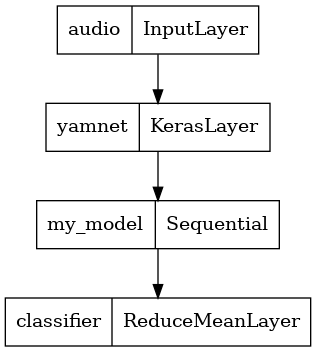

In [ ]:
tf.keras.utils.plot_model(serving_model)

Load your saved model to verify that it works as expected.

In [ ]:
reloaded_model = tf.saved_model.load(saved_model_path)

And for the final test: given some sound data, does your model return the correct result?

In [ ]:
reloaded_results = reloaded_model(testing_wav_data)
cat_or_dog = my_classes[tf.math.argmax(reloaded_results)]
print(f'The main sound is: {cat_or_dog}')

The main sound is: cat


If you want to try your new model on a serving setup, you can use the 'serving_default' signature.

In [ ]:
serving_results = reloaded_model.signatures['serving_default'](testing_wav_data)
cat_or_dog = my_classes[tf.math.argmax(serving_results['classifier'])]
print(f'The main sound is: {cat_or_dog}')


The main sound is: cat


## (Optional) Some more testing

The model is ready.

Let's compare it to YAMNet on the test dataset.

./datasets/ESC-50-master/audio/5-172299-A-5.wav


Waveform values: [-1.0854422e-06  3.1059460e-06 -1.3652678e-06 ...  1.6882542e-01
  1.3804492e-01  5.8870625e-02]


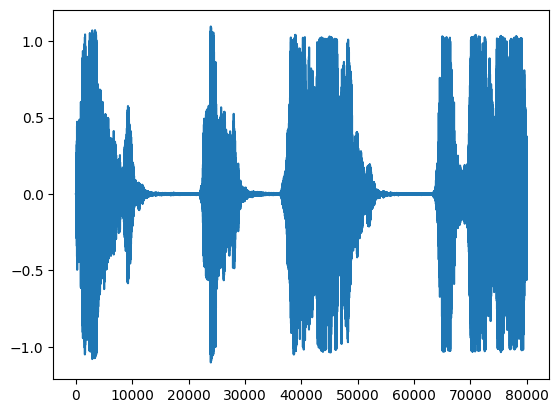

In [ ]:
test_pd = filtered_pd.loc[filtered_pd['fold'] == 5]
row = test_pd.sample(1)
filename = row['filename'].item()
print(filename)
waveform = load_wav_16k_mono(filename)
print(f'Waveform values: {waveform}')
_ = plt.plot(waveform)

display.Audio(waveform, rate=16000)

In [ ]:
# Run the model, check the output.
scores, embeddings, spectrogram = yamnet_model(waveform)
class_scores = tf.reduce_mean(scores, axis=0)
top_class = tf.math.argmax(class_scores)
inferred_class = class_names[top_class]
top_score = class_scores[top_class]
print(f'[YAMNet] The main sound is: {inferred_class} ({top_score})')

reloaded_results = reloaded_model(waveform)
your_top_class = tf.math.argmax(reloaded_results)
your_inferred_class = my_classes[your_top_class]
class_probabilities = tf.nn.softmax(reloaded_results, axis=-1)
your_top_score = class_probabilities[your_top_class]
print(f'[Your model] The main sound is: {your_inferred_class} ({your_top_score})')

[YAMNet] The main sound is: Domestic animals, pets (0.5051151514053345)
[Your model] The main sound is: cat (0.996594250202179)


## Next steps

You have created a model that can classify sounds from dogs or cats. With the same idea and a different dataset you can try, for example, building an [acoustic identifier of birds](https://www.kaggle.com/c/birdclef-2021/) based on their singing.

Share your project with the TensorFlow team on social media!
